In [13]:
import sys, os
sys.path.insert(0, '../../')
from pathlib import Path
import math
import numpy as np
import matplotlib.pyplot as plt 
from gasp import load_dataset, process_data_for_gasp, apply_mask_to_data

import logging
logging.getLogger('gasp.dataset').setLevel(logging.DEBUG)
logging.basicConfig() 

In [14]:
ds = {
    'path':'2025_10_1_bottle_phantom',
    'filter':'_fa20_'
}

M = load_dataset(**ds )
M = np.swapaxes(M, 0, 1)

ds_dixon = {
    'path':'2025_10_1_bottle_phantom',
    'filter': ['_gre_TE3p41', '_gre_TE4p55', '_gre_TE5p68']
}

M_dixon = load_dataset(**ds_dixon)

print('M shape: ', M.shape)
print('M_dixon shape: ', M_dixon.shape)

DEBUG:gasp.dataset:Filter: _fa20_
DEBUG:gasp.dataset:Loading from: /Users/michael/projects/mri/GASP/notebooks/datasets/../../gasp/../data/2025_10_1_bottle_phantom
DEBUG:gasp.dataset:Files: ['meas_MID312_bSSFP_gasp_knee_fa20_TR7ms_FID84941.dat', 'meas_MID313_bSSFP_gasp_knee_fa20_TR14ms_FID84942.dat', 'meas_MID314_bSSFP_gasp_knee_fa20_TR28ms_FID84943.dat']


pymapVBVD version 0.6.1
Software version: VB


pymapVBVD version 0.6.1
Software version: VB


pymapVBVD version 0.6.1
Software version: VB


DEBUG:gasp.dataset:Filter: _gre_TE3p41,_gre_TE4p55,_gre_TE5p68   
DEBUG:gasp.dataset:Loading from: /Users/michael/projects/mri/GASP/notebooks/datasets/../../gasp/../data/2025_10_1_bottle_phantom
DEBUG:gasp.dataset:Files: ['meas_MID303_gre_TE3p41_FID84932.dat', 'meas_MID304_gre_TE4p55_FID84933.dat', 'meas_MID305_gre_TE5p68_FID84934.dat']


pymapVBVD version 0.6.1
Software version: VB


pymapVBVD version 0.6.1
Software version: VB


pymapVBVD version 0.6.1
Software version: VB


M shape:  (256, 256, 8, 16, 3)
M_dixon shape:  (64, 64, 8, 3)


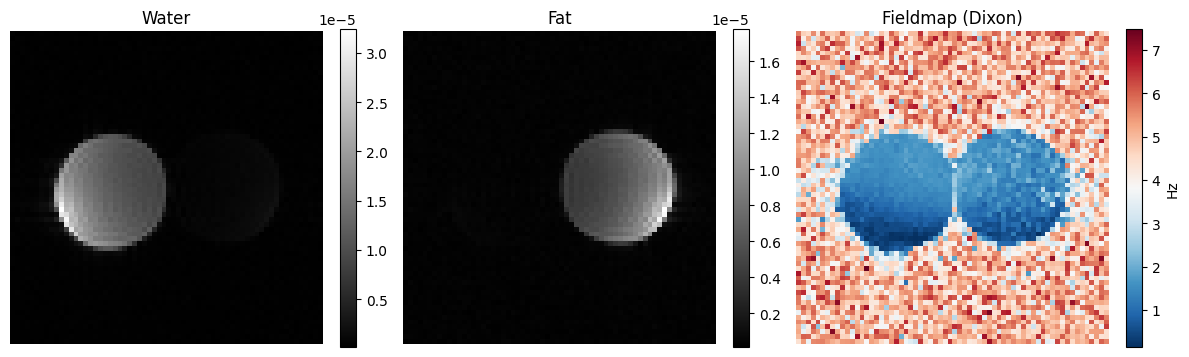

In [15]:
from gasp.analysis import dixon_3pt

Mwater, Mfat, field_map = dixon_3pt(M_dixon)

# Flip horizontally so water is on the left side
Mwater = Mwater.T
Mfat = Mfat.T
field_map = field_map.T

# Plot water, fat, and fieldmap in 3 columns
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

im0 = axes[0].imshow(Mwater, cmap='gray')
axes[0].set_title('Water')
axes[0].axis('off')
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(Mfat, cmap='gray')
axes[1].set_title('Fat')
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], fraction=0.046)

im2 = axes[2].imshow(field_map, cmap='RdBu_r')
axes[2].set_title('Fieldmap (Dixon)')
axes[2].axis('off')
plt.colorbar(im2, ax=axes[2], label='Hz', fraction=0.046)

plt.tight_layout()
plt.show()

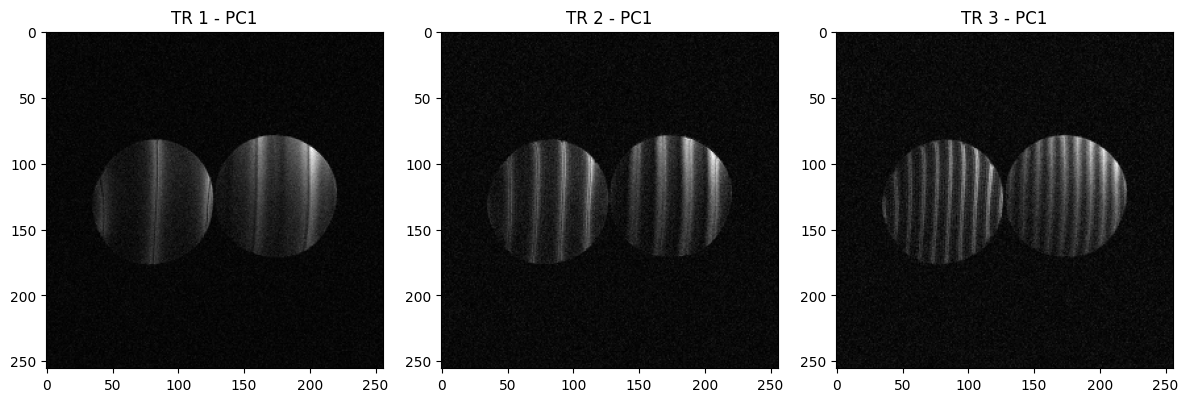

In [16]:
import numpy as np
import matplotlib.pyplot as plt

cc = 2
pc = 14

# M shape: (Height, Width, Coil, PCs, TRs)
# Combine coils using root sum of squares (optimal for magnitude)
M_rss = np.sqrt(np.sum(np.abs(M)**2, axis=2))  # shape: (H, W, PCs, TRs)

# Extract first PC (index 0) for all 3 TRs
first_pc = M_rss[:, :, 0, :]  # shape: (H, W, TRs)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i in range(3):
    im = axes[i].imshow(np.abs(M[:, :, cc, pc, i]), cmap='gray')
    axes[i].set_title(f'TR {i+1} - PC1')
    #axes[i].axis('off')
    #plt.colorbar(im, ax=axes[i], fraction=0.046)
plt.tight_layout()
plt.show()

Water Phantom: 80


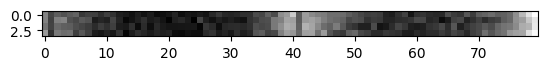

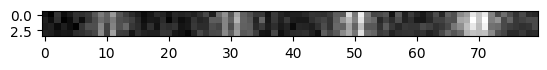

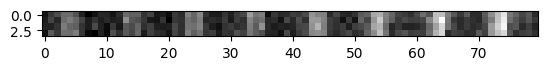

Fat Phantom: {x1-x0}


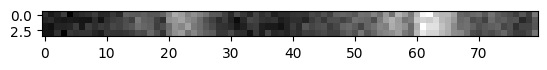

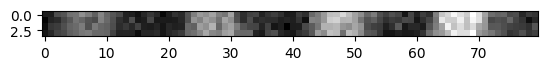

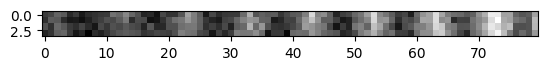

In [17]:
# Isolate lines of phantom
lines = 4

y = 130
x0 = 42; x1 = x0 + 80 
y0 = y-lines//2; y1 = y+lines//2
waterData = M[y0:y1, x0:x1, :,:,:]

print(f'Water Phantom: {x1-x0}')
plt.imshow(np.abs(waterData[:,:,cc,pc,0]), cmap='gray')
plt.show() 
plt.imshow(np.abs(waterData[:,:,cc,pc,1]), cmap='gray')
plt.show() 
plt.imshow(np.abs(waterData[:,:,cc,pc,2]), cmap='gray')
plt.show() 

y = 130
x0 = 140; x1 = x0 + 80
y0 = y-lines//2; y1 = y+lines//2
fatData = M[y0:y1, x0:x1, :,:,:]

print('Fat Phantom: {x1-x0}')
plt.imshow(np.abs(fatData[:,:,cc,pc,0]), cmap='gray')
plt.show() 
plt.imshow(np.abs(fatData[:,:,cc,pc,1]), cmap='gray')
plt.show() 
plt.imshow(np.abs(fatData[:,:,cc,pc,2]), cmap='gray')
plt.show() 



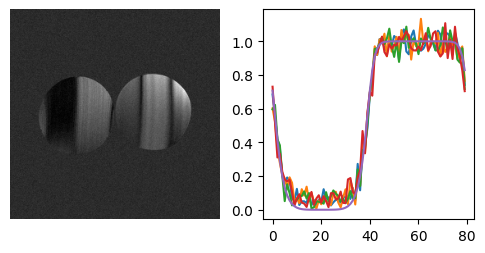

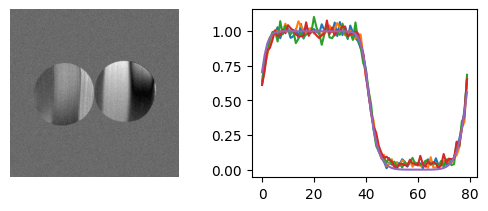

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import gasp
from gasp import responses

METHOD = 'affine'

D = responses.bandpass(width=waterData.shape[1], bw=0.5, shift=0.25)
I, Awater = gasp.train_gasp(waterData[:,:,cc,:,:], D, method=METHOD)
out = gasp.run_gasp(M[:,:,cc,:,:], Awater, method=METHOD)

plt.figure(figsize=(6, 6))
plt.subplot(2,2,1)
plt.imshow(np.abs(out), cmap='gray')
plt.axis('off')
plt.subplot(2,2,2)
plt.plot(np.abs(I.T))
plt.plot(D)
plt.show()

D = responses.bandpass(width=fatData.shape[1], bw=0.5, shift=-0.25)
I, Afat = gasp.train_gasp(fatData[:,:,cc,:,:], D, method=METHOD)
out = gasp.run_gasp(M[:,:,cc,:,:], Afat, method=METHOD)

plt.subplot(2,2,3)
plt.imshow(np.abs(out), cmap='gray')
plt.axis('off')

plt.subplot(2,2,4)
plt.plot(np.abs(I.T))
plt.plot(D)
plt.show()

In [19]:
ds = {
    'path':'2025_10_1_bottle_phantom_nograd',
    'filter':'_fa20_'
}

Mnograd = load_dataset(**ds )
Mnograd = np.swapaxes(Mnograd, 0, 1)

ds_fieldmap = { 
    'path':'2025_10_1_bottle_phantom_nograd',
    'filter': 'gre_field_mapping',
    'description': 'GRE field mapping with TE1 = 4.92ms and TE2 = 7.38ms'
}

M_nograd_fieldmap = load_dataset(**ds_fieldmap)

ds_dixon = {
    'path':'2025_10_1_bottle_phantom_nograd',
    'filter': ['_gre_TE3p41', '_gre_TE4p55', '_gre_TE5p68']
}

M_nograd_dixon = load_dataset(**ds_dixon)

print('M shape: ', Mnograd.shape)
print('M_fieldmap shape: ', M_nograd_fieldmap.shape)
print('M_dixon shape: ', M_nograd_dixon.shape)

DEBUG:gasp.dataset:Filter: _fa20_
DEBUG:gasp.dataset:Loading from: /Users/michael/projects/mri/GASP/notebooks/datasets/../../gasp/../data/2025_10_1_bottle_phantom_nograd
DEBUG:gasp.dataset:Files: ['meas_MID264_bSSFP_gasp_knee_fa20_TR7ms_FID84893.dat', 'meas_MID265_bSSFP_gasp_knee_fa20_TR14ms_FID84894.dat', 'meas_MID266_bSSFP_gasp_knee_fa20_TR28ms_FID84895.dat']


pymapVBVD version 0.6.1
Software version: VB


pymapVBVD version 0.6.1
Software version: VB


pymapVBVD version 0.6.1
Software version: VB


DEBUG:gasp.dataset:Filter: gre_field_mapping                     
DEBUG:gasp.dataset:Loading from: /Users/michael/projects/mri/GASP/notebooks/datasets/../../gasp/../data/2025_10_1_bottle_phantom_nograd
DEBUG:gasp.dataset:Files: ['meas_MID275_gre_field_mapping_FID84904.dat']


...

DEBUG:gasp.dataset:Filter: _gre_TE3p41,_gre_TE4p55,_gre_TE5p68
DEBUG:gasp.dataset:Loading from: /Users/michael/projects/mri/GASP/notebooks/datasets/../../gasp/../data/2025_10_1_bottle_phantom_nograd
DEBUG:gasp.dataset:Files: ['meas_MID270_gre_TE3p41_FID84899.dat', 'meas_MID271_gre_TE4p55_FID84900.dat', 'meas_MID272_gre_TE5p68_FID84901.dat']


pymapVBVD version 0.6.1
Software version: VB


pymapVBVD version 0.6.1
Software version: VB


pymapVBVD version 0.6.1
Software version: VB


M shape:  (256, 256, 8, 16, 3)
M_fieldmap shape:  (128, 128, 8, 2, 1)
M_dixon shape:  (64, 64, 8, 3)


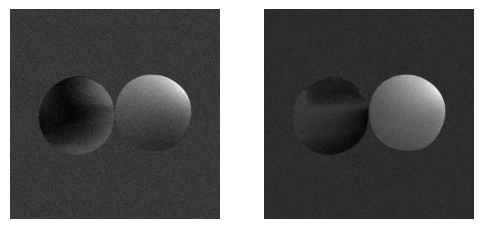

In [20]:
water_img = gasp.run_gasp(Mnograd[:,:,cc,:,:], Awater, method=METHOD)
fat_img = gasp.run_gasp(Mnograd[:,:,cc,:,:], Afat, method=METHOD)

plt.figure(figsize=(6, 6))
plt.subplot(2,2,1)
plt.imshow(np.abs(water_img), cmap='gray')
plt.axis('off')
plt.subplot(2,2,2)
plt.imshow(np.abs(fat_img), cmap='gray')
plt.axis('off')
plt.show()